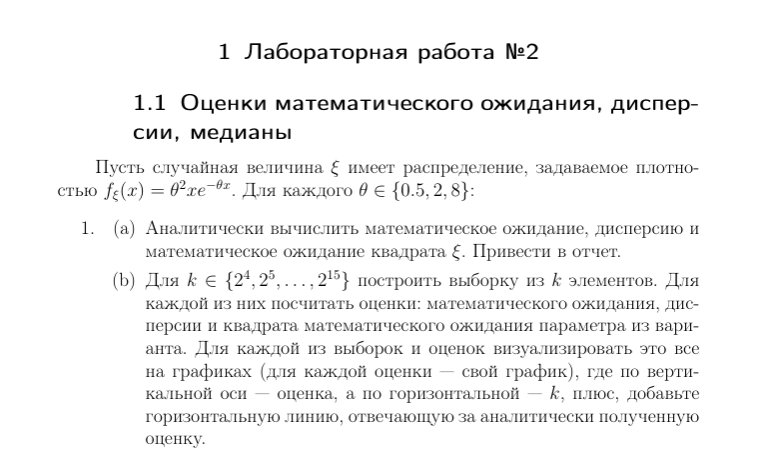

# **Аналитическое решение**

$$f_ξ(x)=θ^2xe^{-θx},$$ для каждого $$θ \in {0.5, 2, 8}$$

$$Eξ=θ^2\int_0^∞ x^2e^{-θx}dx=θ^2⋅\frac{2}{θ^3}=\frac{2}{θ}$$

$$Eξ^2=θ^2\int_0^∞ x^3e^{-θx}dx=θ^2⋅\frac{6}{θ^4}=\frac{6}{θ^2}$$

$$Dξ=Eξ^2-(Eξ)^2=\frac{6}{θ^2}-\frac{4}{θ^2}=\frac{2}{θ^2}$$


| θ | Eξ | Dξ | $$Eξ^2$$|
| :--- | :--- | :--- | :--- |
| 0.5 | 4 | 8 |24|
| 2 | 1 | 0.5 | 1.5|
| 8 | 0.25 | 0.03125 | 0.09375 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. Аналитические значения ==========
def true_mean(theta):
    return 2 / theta

def true_variance(theta):
    return 2 / theta**2

def true_second_moment(theta):
    return 6 / theta**2

# Параметры
theta_values = [0.5, 2.0, 8.0]
k_values = [2**i for i in range(4, 16)]  # 16, 32, 64, ..., 32768


print("АНАЛИТИЧЕСКИЕ ЗНАЧЕНИЯ")

for theta in theta_values:
    print(f"\nθ = {theta}")
    print(f"  Математическое ожидание E[ξ] = {true_mean(theta)}")
    print(f"  Дисперсия Var(ξ) = {true_variance(theta)}")
    print(f"  Второй момент E[ξ²] = {true_second_moment(theta)}")

АНАЛИТИЧЕСКИЕ ЗНАЧЕНИЯ

θ = 0.5
  Математическое ожидание E[ξ] = 4.0
  Дисперсия Var(ξ) = 8.0
  Второй момент E[ξ²] = 24.0

θ = 2.0
  Математическое ожидание E[ξ] = 1.0
  Дисперсия Var(ξ) = 0.5
  Второй момент E[ξ²] = 1.5

θ = 8.0
  Математическое ожидание E[ξ] = 0.25
  Дисперсия Var(ξ) = 0.03125
  Второй момент E[ξ²] = 0.09375


In [ ]:
# ========== 2. Генерация выборки ==========
def generate_erlang_sample(shape=2, rate=1.0, size=1):
    """
    Генерация выборки из распределения Эрланга (Gamma с целым shape)
    через сумму независимых экспоненциальных.
    Для shape=2: ξ = X1 + X2, где Xi ~ Exp(rate)
    """
    samples = []
    for _ in range(size):
        # Сумма двух экспоненциальных
        x1 = np.random.exponential(scale=1/rate)  # scale = 1/λ
        x2 = np.random.exponential(scale=1/rate)
        samples.append(x1 + x2)
    return np.array(samples)

In [ ]:
results = {}
for theta in theta_values:
    print(f"\nОбработка θ = {theta}...")
    estimates = {
        'mean': [],
        'variance': [],
        'second_moment': []
    }

    for k in k_values:
        # Генерируем выборку
        sample = generate_erlang_sample(shape=2, rate=theta, size=k)

        # Вычисляем оценки
        est_mean = np.mean(sample)
        est_var = np.var(sample, ddof=1)  # несмещенная оценка дисперсии
        est_second = np.mean(sample**2)

        estimates['mean'].append(est_mean)
        estimates['variance'].append(est_var)
        estimates['second_moment'].append(est_second)

    results[theta] = estimates


Обработка θ = 0.5...

Обработка θ = 2.0...

Обработка θ = 8.0...


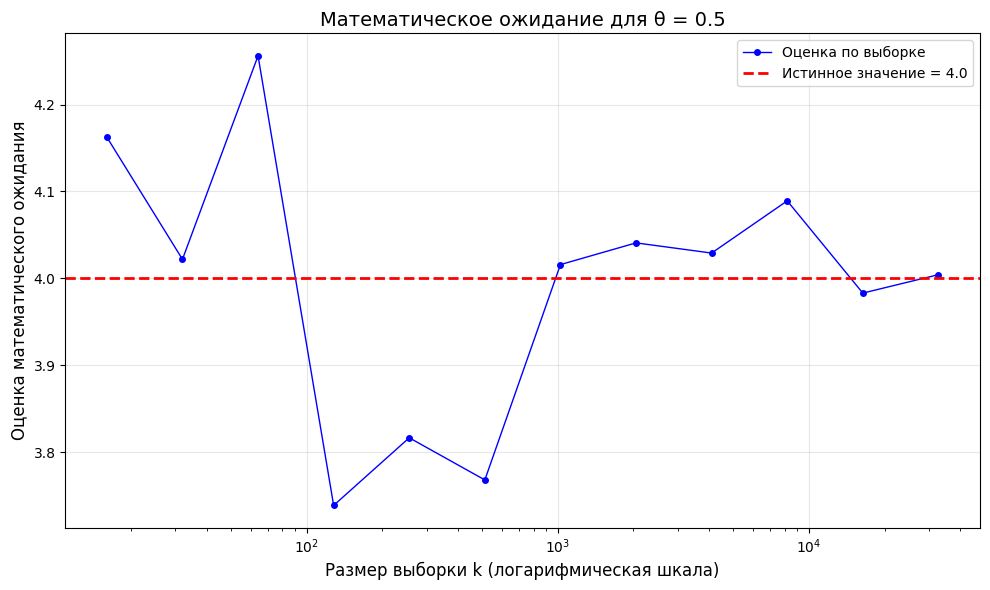

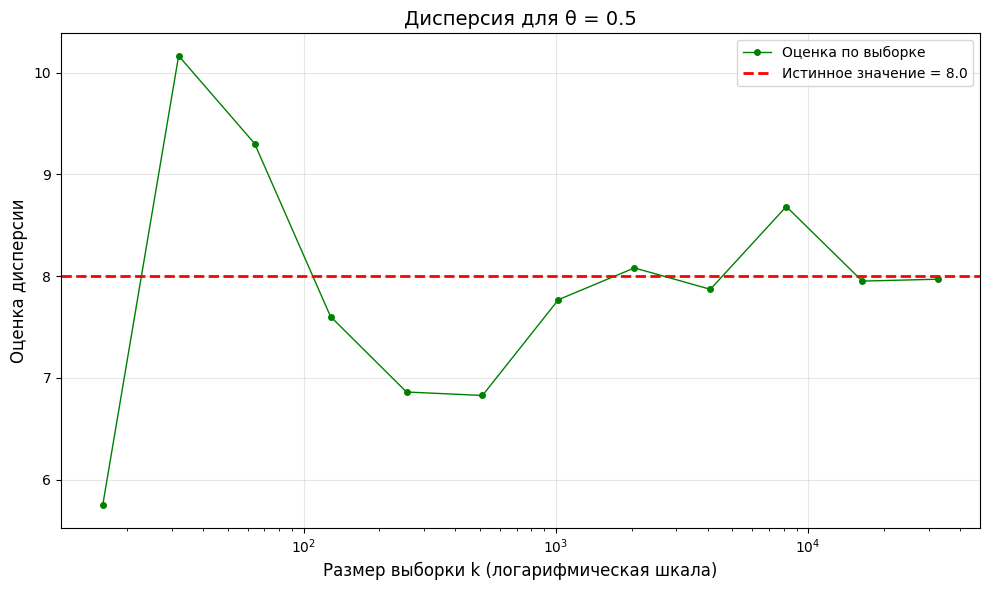

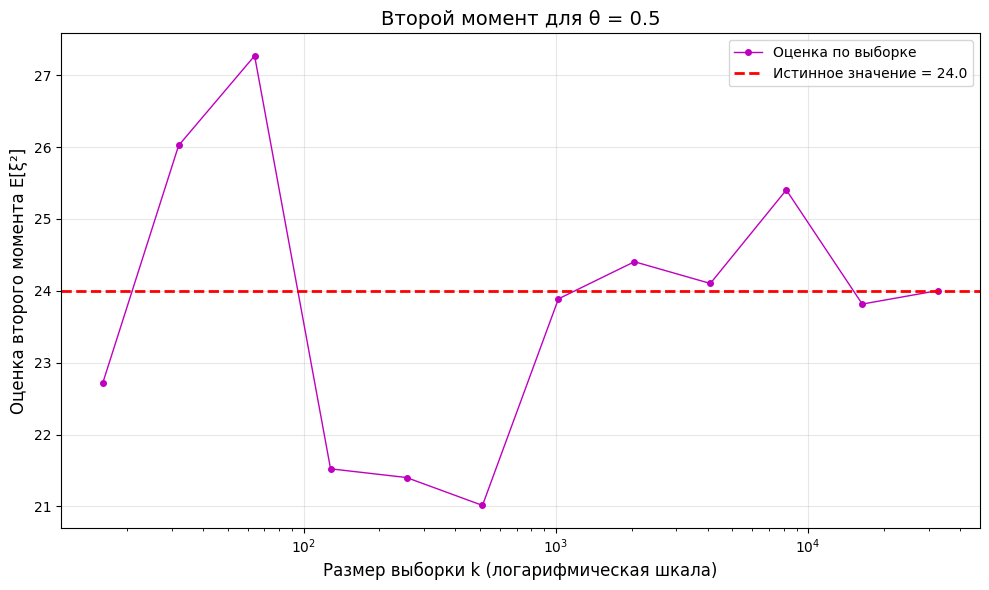

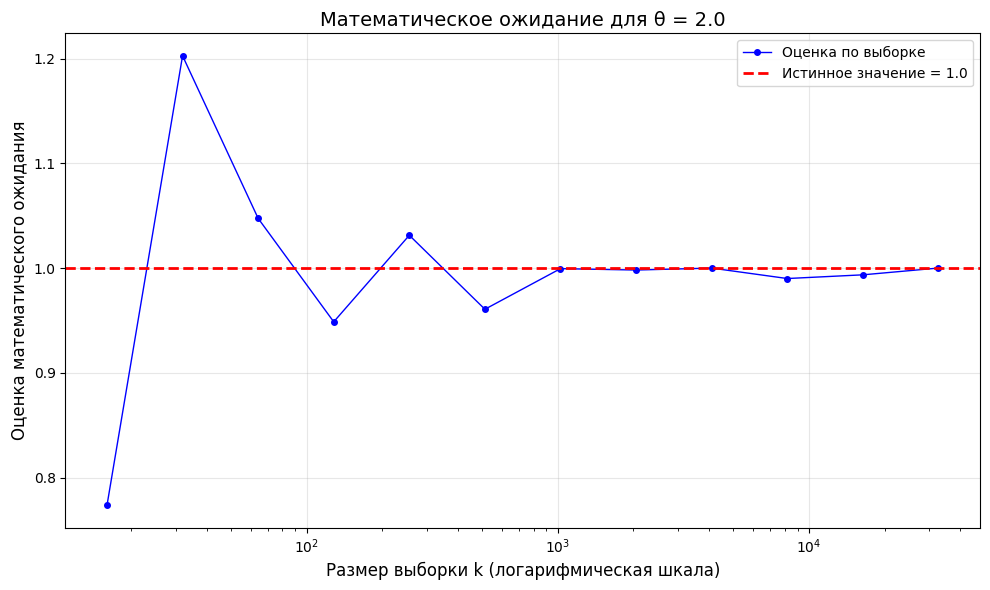

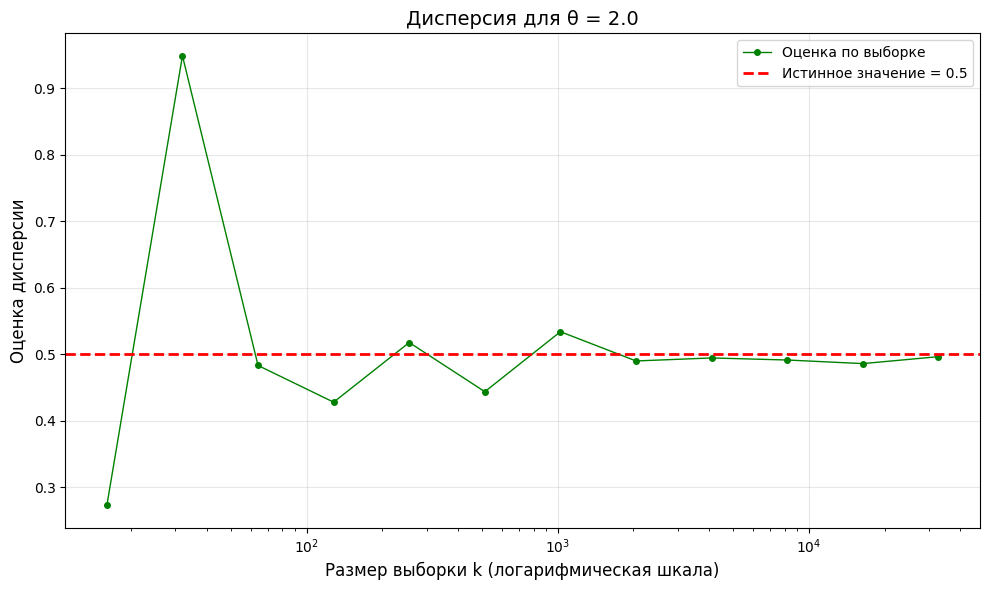

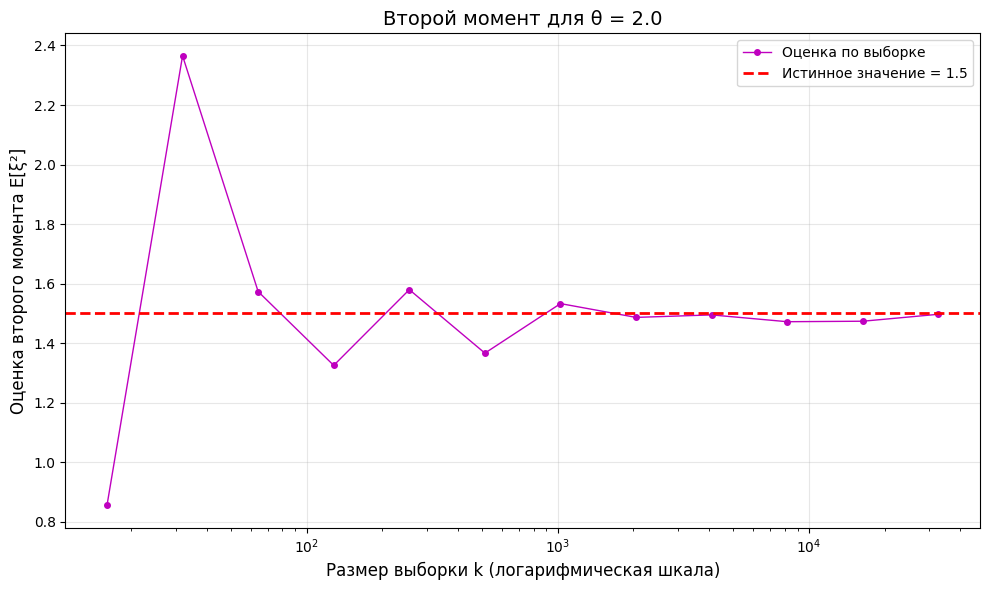

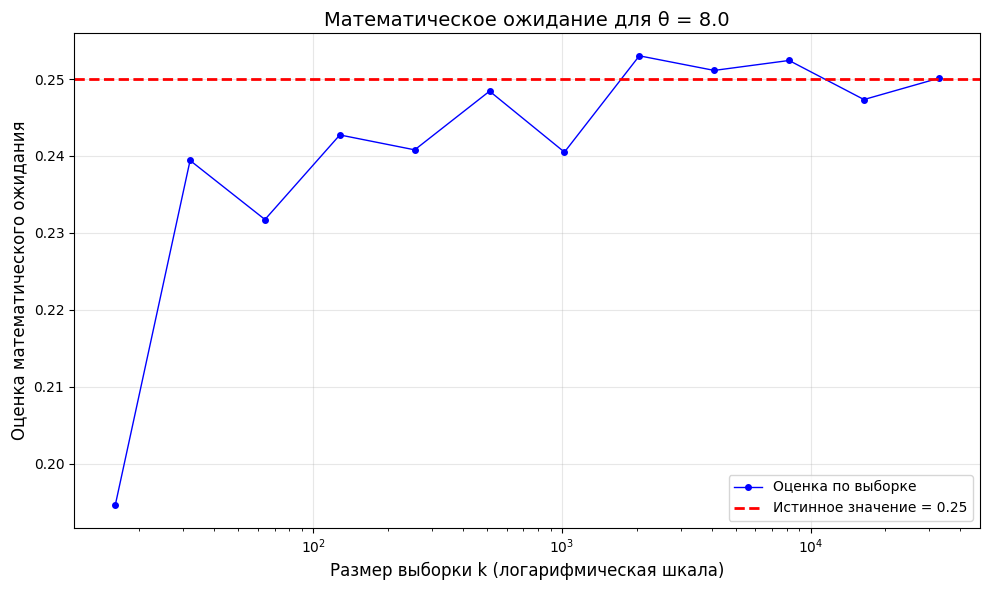

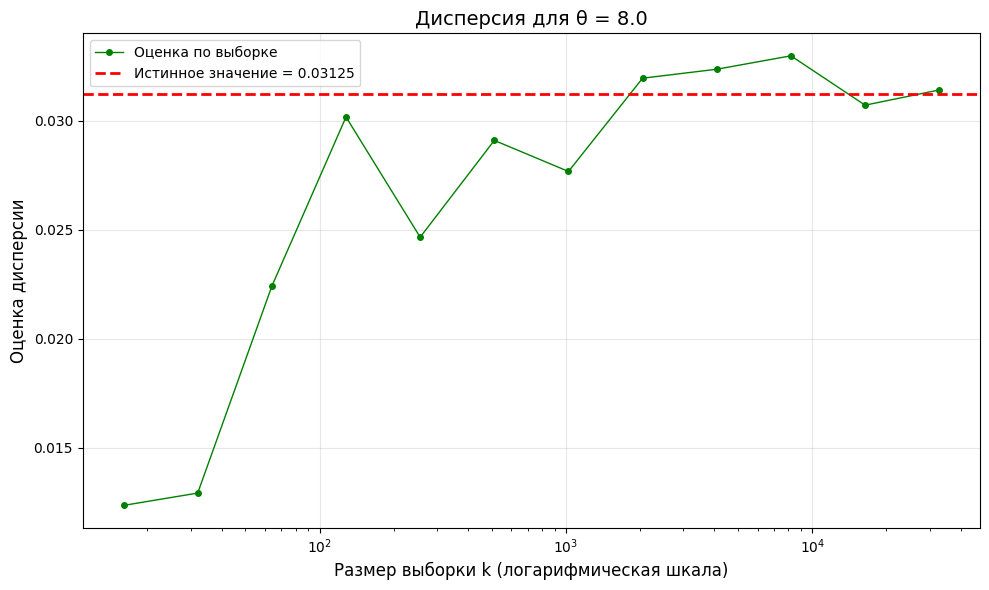

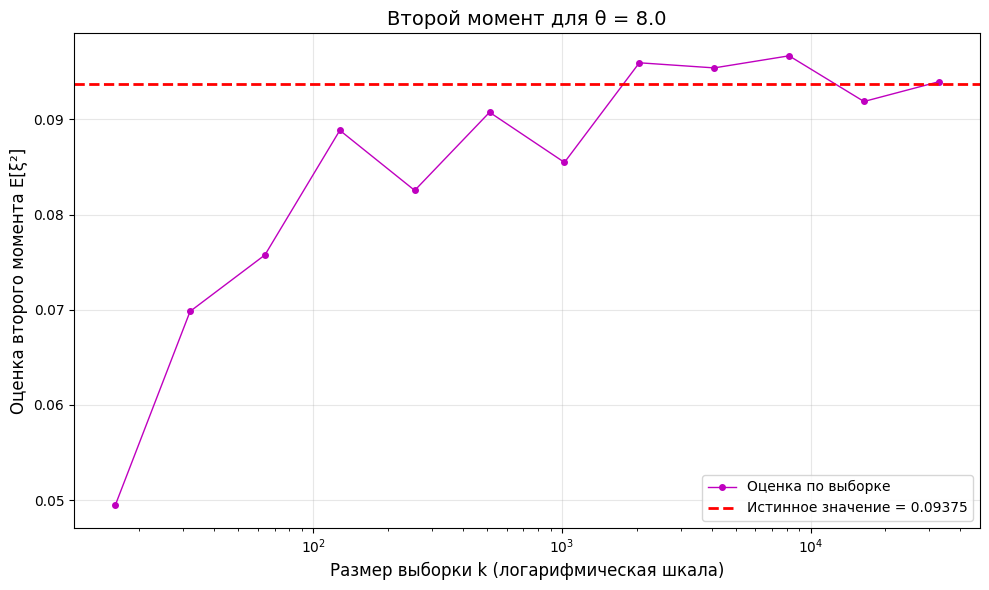

In [ ]:
# ========== 4. Визуализация ==========
for theta in theta_values:
    # Истинные значения
    true_m = true_mean(theta)
    true_v = true_variance(theta)
    true_s = true_second_moment(theta)

    # Получаем оценки для этого theta
    est_m = results[theta]['mean']
    est_v = results[theta]['variance']
    est_s = results[theta]['second_moment']

    # --- График 1: Оценка математического ожидания ---
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, est_m, 'bo-', markersize=4, linewidth=1, label='Оценка по выборке')
    plt.axhline(y=true_m, color='r', linestyle='--', linewidth=2,
                label=f'Истинное значение = {true_m}')
    plt.xscale('log')
    plt.xlabel('Размер выборки k (логарифмическая шкала)', fontsize=12)
    plt.ylabel('Оценка математического ожидания', fontsize=12)
    plt.title(f'Математическое ожидание для θ = {theta}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- График 2: Оценка дисперсии ---
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, est_v, 'go-', markersize=4, linewidth=1, label='Оценка по выборке')
    plt.axhline(y=true_v, color='r', linestyle='--', linewidth=2,
                label=f'Истинное значение = {true_v}')
    plt.xscale('log')
    plt.xlabel('Размер выборки k (логарифмическая шкала)', fontsize=12)
    plt.ylabel('Оценка дисперсии', fontsize=12)
    plt.title(f'Дисперсия для θ = {theta}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- График 3: Оценка второго момента E[ξ²] ---
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, est_s, 'mo-', markersize=4, linewidth=1, label='Оценка по выборке')
    plt.axhline(y=true_s, color='r', linestyle='--', linewidth=2,
                label=f'Истинное значение = {true_s}')
    plt.xscale('log')
    plt.xlabel('Размер выборки k (логарифмическая шкала)', fontsize=12)
    plt.ylabel('Оценка второго момента E[ξ²]', fontsize=12)
    plt.title(f'Второй момент для θ = {theta}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

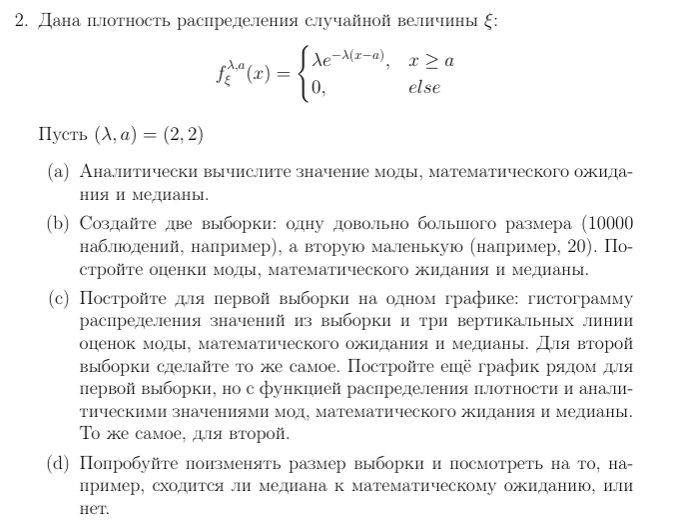

# **Аналитическое решение**

Мода - точка максимума плотности.
Экспоненциальное распределение убывает монотонно, значит мода в начале носителя: $$Мода=a=2$$


$$Eξ=\int_2^∞ x\cdot 2e^{-2(x-2)}dx=2.5$$

Функция распределения:

$$F(x)=0$$

при $$x<2$$
а при $$x \geq 2$$

$$F(x)=\int_2^x 2e^{-2(t-2)}dt=1-e^{-2(x-2)}$$


медиана - это такое m, при котором $$F(m)=0.5$$

$$m \geq 2$$

$$1-e^{-2(m-2)}=0.5$$

$$m=2+\frac{ln2}{2}=2.3466$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Параметры
lambd = 2.0
a = 2.0
true_mode = a
true_mean = a + 1/lambd
true_median = a + np.log(2)/lambd

# Размеры выборок
n_large = 10000
n_small = 20

# Генерация (сдвинутое экспоненциальное)
def rshifted_exp(n, loc, scale):
    return np.random.exponential(scale=1/lambd, size=n) + a

np.random.seed(42)  # для воспроизводимости
large_sample = rshifted_exp(n_large, a, 1/lambd)
small_sample = rshifted_exp(n_small, a, 1/lambd)


In [ ]:
# Оценки
def estimate_mode(sample, bins=50):
    # простейшая оценка моды: центр самого высокого бина гистограммы
    hist, bin_edges = np.histogram(sample, bins=bins)
    peak_idx = np.argmax(hist)
    mode_est = (bin_edges[peak_idx] + bin_edges[peak_idx+1]) / 2
    return mode_est

mean_est_large = np.mean(large_sample)
median_est_large = np.median(large_sample)
mode_est_large = estimate_mode(large_sample, bins=50)

mean_est_small = np.mean(small_sample)
median_est_small = np.median(small_sample)
mode_est_small = estimate_mode(small_sample, bins=20)  # меньше бинов для маленькой выборки

print("=== Большая выборка (n=10000) ===")
print(f"Оценка моды:     {mode_est_large:.4f} (истинная: {true_mode})")
print(f"Оценка мат.ожид.:{mean_est_large:.4f} (истинная: {true_mean})")
print(f"Оценка медианы:  {median_est_large:.4f} (истинная: {true_median:.4f})")

print("\n=== Маленькая выборка (n=20) ===")
print(f"Оценка моды:     {mode_est_small:.4f} (истинная: {true_mode})")
print(f"Оценка мат.ожид.:{mean_est_small:.4f} (истинная: {true_mean})")
print(f"Оценка медианы:  {median_est_small:.4f} (истинная: {true_median:.4f})")


=== Большая выборка (n=10000) ===
Оценка моды:     2.0409 (истинная: 2.0)
Оценка мат.ожид.:2.4887 (истинная: 2.5)
Оценка медианы:  2.3392 (истинная: 2.3466)

=== Маленькая выборка (n=20) ===
Оценка моды:     2.0363 (истинная: 2.0)
Оценка мат.ожид.:2.4125 (истинная: 2.5)
Оценка медианы:  2.2788 (истинная: 2.3466)


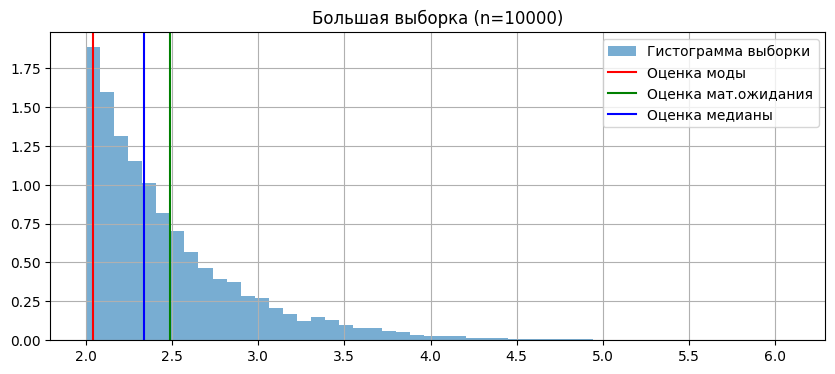

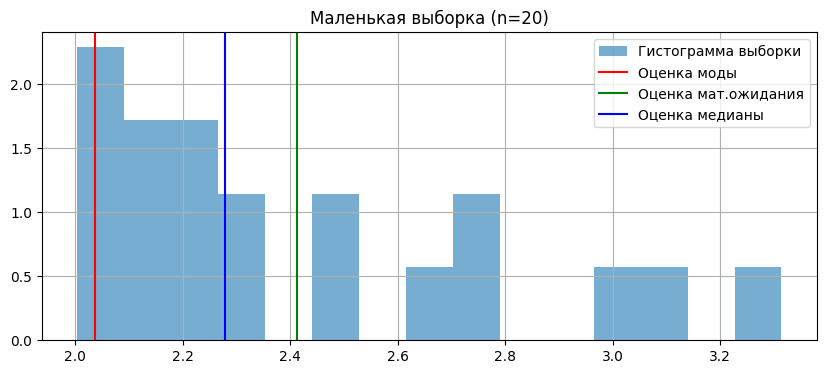

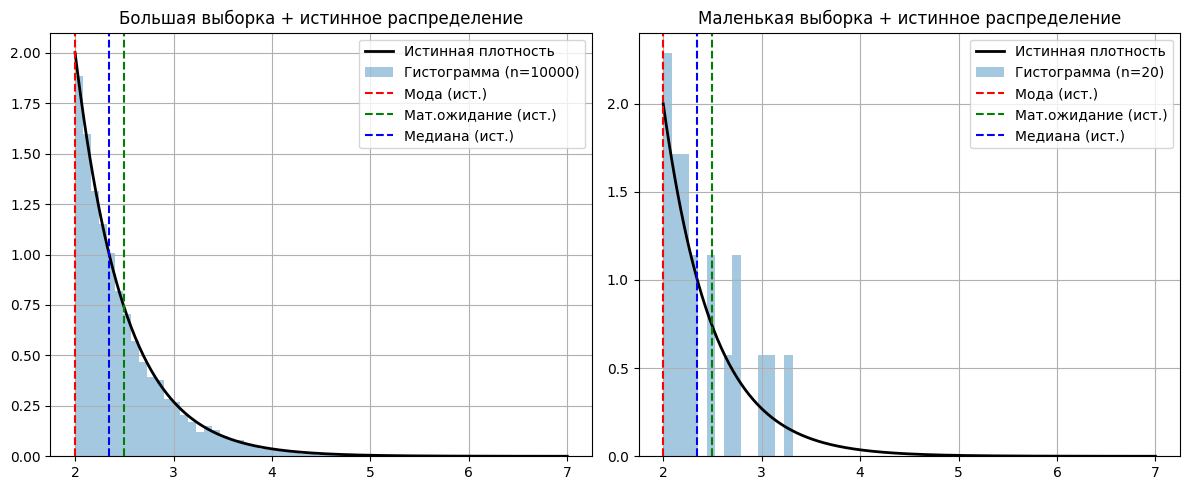

In [ ]:
# ---- (c) Графики ----
# Первая выборка (большая) — гистограмма + вертикальные линии
plt.figure(figsize=(10, 4))
plt.hist(large_sample, bins=50, density=True, alpha=0.6, label='Гистограмма выборки')
plt.axvline(mode_est_large, color='r', linestyle='-', label='Оценка моды')
plt.axvline(mean_est_large, color='g', linestyle='-', label='Оценка мат.ожидания')
plt.axvline(median_est_large, color='b', linestyle='-', label='Оценка медианы')
plt.title('Большая выборка (n=10000)')
plt.legend()
plt.grid(True)
plt.show()

# Вторая выборка (маленькая)
plt.figure(figsize=(10, 4))
plt.hist(small_sample, bins=15, density=True, alpha=0.6, label='Гистограмма выборки')
plt.axvline(mode_est_small, color='r', linestyle='-', label='Оценка моды')
plt.axvline(mean_est_small, color='g', linestyle='-', label='Оценка мат.ожидания')
plt.axvline(median_est_small, color='b', linestyle='-', label='Оценка медианы')
plt.title('Маленькая выборка (n=20)')
plt.legend()
plt.grid(True)
plt.show()

# Те же выборки, но с истинной плотностью и истинными значениями
x_vals = np.linspace(a, a + 5, 500)
pdf_vals = lambd * np.exp(-lambd * (x_vals - a))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_vals, pdf_vals, 'k-', linewidth=2, label='Истинная плотность')
plt.hist(large_sample, bins=50, density=True, alpha=0.4, label='Гистограмма (n=10000)')
plt.axvline(true_mode, color='r', linestyle='--', label='Мода (ист.)')
plt.axvline(true_mean, color='g', linestyle='--', label='Мат.ожидание (ист.)')
plt.axvline(true_median, color='b', linestyle='--', label='Медиана (ист.)')
plt.title('Большая выборка + истинное распределение')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_vals, pdf_vals, 'k-', linewidth=2, label='Истинная плотность')
plt.hist(small_sample, bins=15, density=True, alpha=0.4, label='Гистограмма (n=20)')
plt.axvline(true_mode, color='r', linestyle='--', label='Мода (ист.)')
plt.axvline(true_mean, color='g', linestyle='--', label='Мат.ожидание (ист.)')
plt.axvline(true_median, color='b', linestyle='--', label='Медиана (ист.)')
plt.title('Маленькая выборка + истинное распределение')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

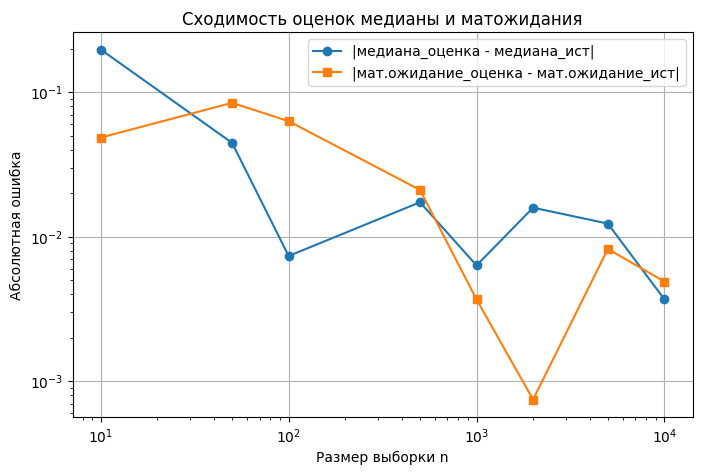

In [ ]:
# ---- (d) Сходимость медианы к матожиданию ----
# Проверяем для разных n
n_vals = [10, 50, 100, 500, 1000, 2000, 5000, 10000]
median_errors = []
mean_errors = []

for n in n_vals:
    sample = rshifted_exp(n, a, 1/lambd)
    median_est = np.median(sample)
    mean_est = np.mean(sample)
    median_errors.append(abs(median_est - true_median))
    mean_errors.append(abs(mean_est - true_mean))

plt.figure(figsize=(8, 5))
plt.plot(n_vals, median_errors, 'o-', label='|медиана_оценка - медиана_ист|')
plt.plot(n_vals, mean_errors, 's-', label='|мат.ожидание_оценка - мат.ожидание_ист|')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Размер выборки n')
plt.ylabel('Абсолютная ошибка')
plt.title('Сходимость оценок медианы и матожидания')
plt.legend()
plt.grid(True)
plt.show()

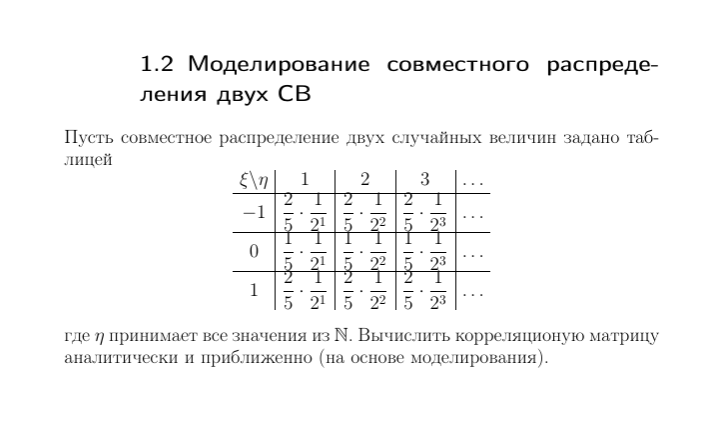

# **Аналитическое вычисление корреляционной матрицы**

Исходные данные

Совместное распределение случайных величин $\xi$ и $\eta$ задано таблицей:

$$
P(\xi = x_i, \eta = j) =
\begin{cases}
\dfrac{2}{5} \cdot \dfrac{1}{2^j}, & x_i = -1 \\[10pt]
\dfrac{1}{5} \cdot \dfrac{1}{2^j}, & x_i = 0 \\[10pt]
\dfrac{2}{5} \cdot \dfrac{1}{2^j}, & x_i = 1
\end{cases}
$$
где $j \in \mathbb{N} = \{1, 2, 3, \dots\}$.

Отсюда видно, что совместное распределение факторизуется:
$$
P(\xi = x_i, \eta = j) = P(\xi = x_i) \cdot P(\eta = j)
$$
Следовательно, $\xi$ и $\eta$ - независимые случайные величины.

Маргинальные распределения:
$$
P(\xi = -1) = \frac{2}{5}, \quad
P(\xi = 0) = \frac{1}{5}, \quad
P(\xi = 1) = \frac{2}{5}
$$
$$
P(\eta = j) = \frac{1}{2^j}, \quad j = 1, 2, 3, \dots
$$

# **Математические ожидания**



$$
E\xi = (-1) \cdot \frac{2}{5} + 0 \cdot \frac{1}{5} + 1 \cdot \frac{2}{5}
= -\frac{2}{5} + 0 + \frac{2}{5} = 0
$$



$$
E\eta = \sum_{j=1}^{\infty} j \cdot \frac{1}{2^j}
$$

Используем формулу для суммы ряда при $|r| < 1$:
$$
\sum_{j=1}^{\infty} j r^j = \frac{r}{(1-r)^2}
$$

Подставляем $r = \dfrac{1}{2}$:
$$
E\eta = \frac{\frac{1}{2}}{\left(1 - \frac{1}{2}\right)^2}
= \frac{\frac{1}{2}}{\left(\frac{1}{2}\right)^2}
= \frac{\frac{1}{2}}{\frac{1}{4}} = 2
$$



В силу независимости:
$$
E\xi\eta = E\xi \cdot E\eta = 0 \cdot 2 = 0
$$

Дисперсии:



$$
D\xi = E(\xi^2) - (E\xi)^2 = E(\xi^2)
$$

$$
E(\xi^2) = (-1)^2 \cdot \frac{2}{5} + 0^2 \cdot \frac{1}{5} + 1^2 \cdot \frac{2}{5}
= \frac{2}{5} + 0 + \frac{2}{5} = \frac{4}{5}
$$

Таким образом:
$$
D(\xi) = \frac{4}{5} = 0.8
$$



$$
D(\eta) = E(\eta^2) - (E(\eta))^2
$$

Сначала найдём $E(\eta^2)$:
$$
E(\eta^2) = \sum_{j=1}^{\infty} j^2 \cdot \frac{1}{2^j}
$$

Используем формулу:
$$
\sum_{j=1}^{\infty} j^2 r^j = \frac{r(1+r)}{(1-r)^3}, \quad |r| < 1
$$

При $r = \dfrac{1}{2}$:
$$
E(\eta^2) = \frac{\frac{1}{2}\left(1 + \frac{1}{2}\right)}{\left(1 - \frac{1}{2}\right)^3}
= \frac{\frac{1}{2} \cdot \frac{3}{2}}{\left(\frac{1}{2}\right)^3}
= \frac{\frac{3}{4}}{\frac{1}{8}} = \frac{3}{4} \cdot 8 = 6
$$

Теперь:
$$
D(\eta) = 6 - 2^2 = 6 - 4 = 2
$$

Ковариация и коэффициент корреляции



$$
\operatorname{Cov}(\xi, \eta) = E(\xi\eta) - E(\xi)E(\eta) = 0 - 0 \cdot 2 = 0
$$

Коэффициент корреляции

$$
\rho_{\xi,\eta} = \frac{\operatorname{Cov}(\xi, \eta)}{\sqrt{D(\xi)\,D(\eta)}}
= \frac{0}{\sqrt{0.8 \cdot 2}} = 0
$$
Ковариационная и корреляционная матрицы


 \begin{pmatrix}
\dfrac{4}{5} & 0 \\[6pt]
0 & 2
\end{pmatrix}

и

 \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
n_samples = 10000

# Генерация выборки
xi_vals = [-1, 0, 1]
xi_probs = [2/5, 1/5, 2/5]

xi_sample = np.random.choice(xi_vals, size=n_samples, p=xi_probs)


eta_sample = np.random.geometric(p=0.5, size=n_samples)

# Проверим, что независимы - перемешивать не нужно, т.к. генерируем независимо

# Оценки моментов
mean_xi_est = np.mean(xi_sample)
mean_eta_est = np.mean(eta_sample)

var_xi_est = np.var(xi_sample, ddof=1)
var_eta_est = np.var(eta_sample, ddof=1)

cov_est = np.cov(xi_sample, eta_sample, ddof=1)[0,1]
corr_est = np.corrcoef(xi_sample, eta_sample)[0,1]

# Корреляционная матрица (выборочная)
corr_matrix_est = np.cov(xi_sample, eta_sample, ddof=1)

print("=== Аналитические значения ===")
print(f"E[ξ] = 0")
print(f"E[η] = 2")
print(f"Var(ξ) = 0.8")
print(f"Var(η) = 2")
print(f"Cov(ξ,η) = 0")
print(f"Корреляция = 0\n")

print("=== Оценки по выборке (n={}) ===".format(n_samples))
print(f"E[ξ] ≈ {mean_xi_est:.4f}")
print(f"E[η] ≈ {mean_eta_est:.4f}")
print(f"Var(ξ) ≈ {var_xi_est:.4f}")
print(f"Var(η) ≈ {var_eta_est:.4f}")
print(f"Cov(ξ,η) ≈ {cov_est:.6f}")
print(f"Корреляция ≈ {corr_est:.6f}\n")

print("Корреляционная матрица (выборочная):")
print(corr_matrix_est)






=== Аналитические значения ===
E[ξ] = 0
E[η] = 2
Var(ξ) = 0.8
Var(η) = 2
Cov(ξ,η) = 0
Корреляция = 0

=== Оценки по выборке (n=10000) ===
E[ξ] ≈ 0.0146
E[η] ≈ 1.9889
Var(ξ) ≈ 0.7957
Var(η) ≈ 1.9226
Cov(ξ,η) ≈ 0.006663
Корреляция ≈ 0.005387

Корреляционная матрица (выборочная):
[[0.79566641 0.00666273]
 [0.00666273 1.92256905]]
